# Powered & De-Confounded Self-Consistency CLUTRR knockoff+ FDR Calibration Diagonal

**Demo of the offline statistical core (Iter-4 P1).**

This artifact studies a *label-free* gate that decides which LLM-extracted kinship facts to
admit into a symbolic reasoning layer. Instead of trusting the model's raw confidence, every
extracted **real** fact is made to *compete* against a matched **counterfactual decoy** fact.
The signed-max competition statistic

$$W_i = \operatorname{sign}(Z_i - \tilde Z_i)\cdot\max(Z_i, \tilde Z_i)$$

feeds the **knockoff+ threshold** (Barber–Candès 2015, eq. 1.9), which is supposed to control the
false discovery rate (FDR) at a target level $\alpha$ *without any gold labels*.

**The question this demo reproduces:** does the gate's promise hold? We build the
**realized-FDR-vs-target-$\alpha$ calibration diagonal** per fact family (`atomic` vs `multi_hop`)
and check it against *crisp CLUTRR gold*. A perfectly calibrated gate sits on (or below) the
$y=x$ diagonal.

The full run extracts and scores ~593 documents with `openai/gpt-4.1-nano` (K=5 self-consistency).
**This demo needs no API calls and no GPU**: it loads ~100 cached per-real records — each already
carrying its self-consistency score `z_real_sc`, its decoy score `z_decoy_sc`, the precomputed
`W` statistic, the raw confidence (for the purely-neural baseline) and the crisp gold label — and
re-runs the *exact* statistical core (`fdr_core.py` / `fdr_stats.py`) on them.

**Headline finding (preserved in this subset):** on `multi_hop` facts the realized FDR blows past
the target (anti-conservative → the calibration claim is **DISCONFIRMED**), while on `atomic` facts
the gate stays conservative. The gate is only as good as the extractor's ability to separate true
from false on a given family.


In [1]:
# --- Install dependencies (works on Colab AND local Jupyter) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy / scipy / matplotlib are pre-installed on Colab — installing ANY version there corrupts
# the pre-loaded C extensions, so only install them locally (at Colab's exact versions).
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
# --- Imports (original method.py / fdr_stats.py import block + matplotlib for the figure) ---
import json, os, math
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


In [3]:
# --- Data loading helper: GitHub URL (Colab) with local fallback (now) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6db730-decoy-gated-neuro-symbolic-extraction-a/main/round-4/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")


In [4]:
data = load_data()

print("dataset :", data["dataset"])
print("records :", len(data["examples"]))
print()
print("hyperparameters (full run):")
for k, v in data["hyperparameters"].items():
    print(f"  {k:18s}: {v}")
print()
print("models:", data["models"])
# peek one cached per-real record
ex0 = data["examples"][0]
print("\nexample record fields:")
for k, v in ex0.items():
    print(f"  {k:24s}: {v}")


dataset : CLUTRR-v1-CrispGold-CalibrationAnchor (demo subset of 100 per-real records)
records : 100

hyperparameters (full run):
  seed              : 20240617
  alpha_grid        : [0.05, 0.1, 0.2, 0.3, 0.5]
  K_self_consistency: 5
  B_bootstrap       : 2000
  tau               : 0.05
  n_false_min       : 40
  W_statistic       : signed-max  W_i = sign(Z_i - Z~_i)*max(Z_i, Z~_i)
  knockoff_plus     : Barber-Candes eq 1.9 (the +1 kept; exact FDR control)

models: {'primary_scorer_and_generator': 'openai/gpt-4.1-nano', 'cross_family_scorer_generator_for_carried_forward_ablation': 'mistralai/ministral-8b-2512'}

example record fields:
  input                   : {"doc_id": "06b7bcc8-d304-428b-ac49-a4c5a18548f9", "head": "Christian", "relation": "father", "tail": "Darren", "claim": "Darren is the father of Christian.", "candidate_kind": "real"}
  output                  : FALSE
  metadata_doc_id         : 06b7bcc8-d304-428b-ac49-a4c5a18548f9
  metadata_fact_type      : atomic
  metadata_

## Configuration

All tunable parameters live here. The bootstrap reps are kept at the full-run values (the compute
is only a few seconds on 100 records); the one knob lowered for the demo subset is `N_FALSE_MIN`.

- `ALPHA_GRID` — the certified target-FDR grid (k-floors are `ceil(1/alpha)`).
- `B_BOOT` / `B_BOOT_INNER` — document-block bootstrap replicates (more = tighter CIs, slower). Set
  to the original full-run values (2000 / 1000). Drop them to e.g. 500 / 200 for an even faster run.
- `N_FALSE_MIN` — minimum genuine-FALSE reals for a family to be **populable** (testable). The full
  run uses 40; this 100-record demo subset has ~28–35 FALSE per family, so we lower it to keep the
  families testable. The certification/disconfirmation *logic* is unchanged.
- `TAU` — tolerance band for the pre-registered disconfirmation.


In [5]:
# ====================== CONFIG (demo values; originals in comments) ======================
ALPHA_GRID   = [0.05, 0.10, 0.20, 0.30, 0.50]   # original: same (k-floors {20,10,5,4,2})
B_BOOT       = 2000         # doc-block bootstrap reps (original full-run value; ~secs on 100 records)
B_BOOT_INNER = 1000         # paired/inner bootstrap reps (original full-run value)
SEED         = 20240617     # original: 20240617
TAU          = 0.05         # original: 0.05  (disconfirmation tolerance band)
N_FALSE_MIN  = 20           # DEMO floor for populability | original full run: 40
# =========================================================================================

# crisp gold labels (verbatim from fdr_core.py)
TRUE, FALSE, UNJUDGEABLE = "TRUE", "FALSE", "UNJUDGEABLE"
print("ALPHA_GRID =", ALPHA_GRID, "| B_BOOT =", B_BOOT, "| N_FALSE_MIN =", N_FALSE_MIN)


ALPHA_GRID = [0.05, 0.1, 0.2, 0.3, 0.5] | B_BOOT = 2000 | N_FALSE_MIN = 20


## The statistical core (`fdr_stats.py` + `fdr_core.py`, verbatim)

These are the pure, API-free, unit-tested primitives copied unchanged from the artifact:

- `W_signed_max` — the canonical signed-max competition statistic.
- `knockoff_plus_threshold` — the data-dependent knockoff+ admission cutoff (the `+1` is kept; it
  controls FDR *exactly*).
- `k_floor` — the `1/k` minimum-estimable-FDR floor.
- `plain_threshold_gate` — the decoy-free **purely-neural baseline** (threshold the model's own
  confidence); it has no null calibration, so it is expected to be over-confident.
- `doc_block_bootstrap` — resample whole documents (preserving within-doc dependence) for CIs.
- `tail_win_rate`, `ks_two_sample` — tail diagnostics for the exchangeability check.

The only edits are dropping the `st.`/`fc.` module prefixes (everything now lives in one namespace)
and removing the type annotations' module imports — the math is byte-for-byte the original.


In [6]:
# ============================================================================
# fdr_stats.py / fdr_core.py  --  pure statistical core (copied verbatim)
# ============================================================================
def W_signed_max(z_real, z_decoy):
    """Signed-max statistic: magnitude = max(real, decoy), sign positive iff real beats decoy
    (Barber-Candes antisymmetry). Scores are rank-normalized to [0,1]."""
    mag = max(z_real, z_decoy)
    s = z_real - z_decoy
    sign = 0.0 if s == 0 else math.copysign(1.0, s)
    return mag * sign


def knockoff_plus_threshold(W, alpha):
    """knockoff+ operative cutoff T(alpha) (Barber-Candes 2015, eq 1.9):
        T = min{ t in |W| : (1 + #{W_i <= -t}) / max(1, #{W_i >= t}) <= alpha }
    The '+1' (Rajchert-Keich: generally necessary) controls EXACT FDR. Returns
    (T, n_admitted, realized_ratio); (inf, 0, 1.0) if no feasible cutoff -> admit nothing."""
    Wa = np.asarray([w for w in W], dtype=float)
    if Wa.size == 0:
        return math.inf, 0, 1.0
    cands = sorted({abs(w) for w in Wa if w != 0.0})
    best = (math.inf, 0, 1.0)
    for t in cands:
        if t <= 0:
            continue
        pos = int(np.sum(Wa >= t))
        neg = int(np.sum(Wa <= -t))
        ratio = (1 + neg) / max(1, pos)
        if ratio <= alpha:
            return float(t), pos, float(ratio)
    return best


def k_floor(alpha):
    """Minimum admissions to certify FDR<=alpha (FDR floor 1/k => k>=ceil(1/alpha))."""
    return int(math.ceil(1.0 / alpha))


def tail_win_rate(pairs, threshold):
    """Among pairs (z_real, z_decoy) with max(z_real,z_decoy) >= T, fraction where the decoy
    beats the real. Target ~0.5 under exchangeability. Returns (win_rate, n_tail)."""
    tail = [(zr, zd) for (zr, zd) in pairs if max(zr, zd) >= threshold]
    if not tail:
        return float("nan"), 0
    wins = sum(1 for (zr, zd) in tail if zd > zr)
    return wins / len(tail), len(tail)


def ks_two_sample(decoy, real, alternative="two-sided"):
    """KS two-sample test. Returns (stat, p)."""
    d = np.asarray(decoy, float)
    r = np.asarray(real, float)
    if d.size == 0 or r.size == 0:
        return float("nan"), 1.0
    try:
        res = stats.ks_2samp(d, r, alternative=alternative, method="auto")
        return float(res.statistic), float(res.pvalue)
    except Exception:
        return float("nan"), 1.0


def doc_block_bootstrap(doc_units, stat_fn, B=2000, seed=0, ci=0.95):
    """Resample WHOLE documents with replacement B times; recompute stat_fn on the pooled
    resample. Returns point estimate, percentile CI, and bootstrap SE."""
    n = len(doc_units)
    point = stat_fn(doc_units)
    if n == 0:
        return {"point": float("nan"), "ci_low": float("nan"), "ci_high": float("nan"),
                "se": float("nan"), "B": B, "n_docs": 0}
    rng = np.random.default_rng(seed)
    reps = np.empty(B)
    idx_all = np.arange(n)
    for b in range(B):
        idx = rng.choice(idx_all, size=n, replace=True)
        resample = [doc_units[i] for i in idx]
        reps[b] = stat_fn(resample)
    reps = reps[~np.isnan(reps)]
    if reps.size == 0:
        return {"point": float(point) if point == point else float("nan"),
                "ci_low": float("nan"), "ci_high": float("nan"),
                "se": float("nan"), "B": B, "n_docs": n}
    lo = float(np.percentile(reps, 100 * (1 - ci) / 2))
    hi = float(np.percentile(reps, 100 * (1 - (1 - ci) / 2)))
    return {"point": float(point) if point == point else float(np.mean(reps)),
            "ci_low": lo, "ci_high": hi, "se": float(np.std(reps, ddof=1)),
            "B": int(reps.size), "n_docs": n}


def plain_threshold_gate(Z, alpha):
    """Decoy-free PURELY-NEURAL baseline: admit the most-confident candidates while the
    self-estimated FDR (1 - mean admitted confidence) <= alpha. No null calibration, so its
    self-estimate is expected to be anti-conservative vs the realized FDR against gold.
    Returns (threshold, admitted_indices, est_fdr_of_admitted)."""
    Z = np.asarray(Z, dtype=float)
    n = Z.size
    if n == 0:
        return math.inf, [], 1.0
    order = np.argsort(-Z, kind="stable")
    zsorted = Z[order]
    cumsum = np.cumsum(zsorted)
    best_k = 0
    best_est = 1.0
    for k in range(1, n + 1):
        est_fdr = 1.0 - cumsum[k - 1] / k
        if est_fdr <= alpha:
            best_k = k
            best_est = est_fdr
    if best_k == 0:
        return math.inf, [], 1.0
    threshold = float(zsorted[best_k - 1])
    admitted = sorted(int(i) for i in order[:best_k])
    return threshold, admitted, float(best_est)


def _nan(x):
    if x is None:
        return None
    if isinstance(x, float) and (math.isnan(x) or math.isinf(x)):
        return None
    return round(float(x), 6)


### Fast vectorized helpers (method.py, verbatim)

The doc-block bootstrap re-runs the knockoff+ gate thousands of times, so `method.py` ships
`O(n log n)` vectorized versions that produce identical output to `knockoff_plus_threshold`
(asserted in its self-test). Copied unchanged.


In [7]:
# Vectorized knockoff+ (identical output to knockoff_plus_threshold) for the bootstrap hot loop
def _knockoff_fast(W, alpha):
    Wa = np.asarray(W, dtype=float)
    if Wa.size == 0:
        return math.inf, 0, 1.0
    sW = np.sort(Wa)
    mags = np.unique(np.abs(Wa))
    mags = mags[mags > 0.0]
    if mags.size == 0:
        return math.inf, 0, 1.0
    pos = sW.size - np.searchsorted(sW, mags, side="left")     # #(W >= t)
    neg = np.searchsorted(sW, -mags, side="right")             # #(W <= -t)
    ratio = (1.0 + neg) / np.maximum(1, pos)
    feas = np.nonzero(ratio <= alpha)[0]
    if feas.size == 0:
        return math.inf, 0, 1.0
    i = int(feas[0])                                           # smallest feasible magnitude
    return float(mags[i]), int(pos[i]), float(ratio[i])


def _realized_fast(zr, zd, isfalse, alpha):
    """Realized FDR of the knockoff+ admitted set, fully vectorized."""
    if zr.size == 0:
        return float("nan")
    s = np.sign(zr - zd)
    W = np.where(s == 0, 0.0, np.maximum(zr, zd) * s)
    T, _, _ = _knockoff_fast(W, alpha)
    if math.isinf(T):
        return float("nan")
    adm = W >= T
    n = int(adm.sum())
    if n == 0:
        return float("nan")
    return float((isfalse & adm).sum()) / n


def _doc_arrays(per_doc):
    """Per-document (zr, zd, isfalse) numpy triples for fast bootstrap resampling."""
    out = []
    for v in per_doc.values():
        out.append((np.array([p["zr"] for p in v], float),
                    np.array([p["zd"] for p in v], float),
                    np.array([p["label"] == FALSE for p in v], bool)))
    return out


def _realized_fdr(pairs_flat, alpha):
    if not pairs_flat:
        return float("nan"), 0, 0, None
    W = [p["w"] for p in pairs_flat]
    T, n_adm_pos, ratio = knockoff_plus_threshold(W, alpha)
    if math.isinf(T):
        return float("nan"), 0, 0, None
    adm = [p for p in pairs_flat if p["w"] >= T]
    n = len(adm)
    nf = sum(1 for p in adm if p["label"] == FALSE)
    realized = (nf / n) if n else float("nan")
    return realized, n, nf, ratio


## From cached records to competition pairs

The full pipeline scores every fact with the LLM and stores the rank-normalized scores. Here we
read those cached scores straight out of the demo records and rebuild the per-document
`(z_real, z_decoy, label, W)` pairs — exactly the `_pairs_for` step of `method.py`, but sourced
from the JSON instead of a live API. We build pairs for two decoy sets:

- **`cf`** — the *counterfactual* decoy (the METHOD): a plausible-but-false alternative fact.
- **`swap`** — a random in-document name **swap** decoy (a negative-control baseline).


In [8]:
# Adapter: cached per-real records -> per-document competition pairs (mirrors method.py _pairs_for)
def family_examples(examples, family):
    if family == "pooled":
        return [e for e in examples if e["output"] in (TRUE, FALSE)]
    return [e for e in examples
            if e["metadata_fact_type"] == family and e["output"] in (TRUE, FALSE)]


def pairs_for(examples, family, decoy_key):
    """Per-doc list of {zr, zd, label, doc_id, w, real_id}. Reals of `family` whose real AND
    decoy were both scored. decoy_key 'cf' = counterfactual decoy (METHOD), 'swap' = swap control."""
    zd_field = {"cf": "metadata_z_decoy_sc", "swap": "metadata_z_swap_sc"}[decoy_key]
    per_doc = {}
    for e in family_examples(examples, family):
        zr = e.get("metadata_z_real_sc")
        zd = e.get(zd_field)
        if zr is None or zd is None:
            continue
        per_doc.setdefault(e["metadata_doc_id"], []).append(
            {"zr": zr, "zd": zd, "label": e["output"], "doc_id": e["metadata_doc_id"],
             "w": W_signed_max(zr, zd), "real_id": e["input"]})
    return per_doc


def family_records(examples, family):
    """Family reals (label + raw confidence) for the PLAIN baseline gate."""
    reals = [{"label": e["output"], "cand_id": e["input"],
              "zraw": e.get("metadata_z_real_raw_sc")} for e in family_examples(examples, family)]
    raw_conf = {r["cand_id"]: r["zraw"] for r in reals if r["zraw"] is not None}
    return reals, raw_conf


# quick sanity check
for fam in ("atomic", "multi_hop"):
    pd_cf = pairs_for(data["examples"], fam, "cf")
    flat = [p for v in pd_cf.values() for p in v]
    nf = sum(1 for p in flat if p["label"] == FALSE)
    print(f"{fam:10s}: {len(flat)} pairs over {len(pd_cf)} docs | {nf} genuine-FALSE reals")


atomic    : 50 pairs over 29 docs | 28 genuine-FALSE reals
multi_hop : 50 pairs over 28 docs | 35 genuine-FALSE reals


## The calibration diagonal (`diagonal_for_family`, faithful)

For each target $\alpha$ we:

1. compute the knockoff+ cutoff $T(\alpha)$ and the **admitted** set $\{i: W_i \ge T\}$;
2. record the gate's *self-reported* `decoy_fdr_hat` (the knockoff ratio) and the **realized FDR**
   against crisp gold (`#admitted-FALSE / #admitted`);
3. attach a **document-block bootstrap CI** on the realized FDR;
4. run the two foils on the same reals — the **swap**-decoy control and the **plain** raw-confidence
   baseline;
5. flag `self_report_anti_conservative` when realized FDR exceeds `decoy_fdr_hat` by more than `TAU`;
6. mark the row **certified** only if `n_admitted >= k_floor(alpha)` *and* the family is populable.

We also compute the **paired-exchangeability** diagnostic: the decoy's win-rate over its matched
real among FALSE pairs in the admission tail. A win-rate near 0.5 means the knockoff null holds and
any FDR breach is a *true/false non-separation* effect rather than broken decoys. This is the body
of `diagonal_for_family`, adapted only to take `examples` instead of the live pipe object.


In [9]:
def diagonal_for_family(examples, family):
    """Full diagonal (method / swap / plain) with doc-block bootstrap CIs + the
    (alpha, decoy_fdr_hat, realized) TRIPLE + the pre-registered SELF-REPORT check."""
    per_doc_cf = pairs_for(examples, family, "cf")
    per_doc_sw = pairs_for(examples, family, "swap")
    flat_cf = [p for v in per_doc_cf.values() for p in v]
    flat_sw = [p for v in per_doc_sw.values() for p in v]
    doc_arrays_cf = _doc_arrays(per_doc_cf)
    famreals, raw_conf = family_records(examples, family)
    n_false_total = sum(1 for c in famreals if c["label"] == FALSE)
    n_true_total = sum(1 for c in famreals if c["label"] == TRUE)
    populable = n_false_total >= N_FALSE_MIN
    n_pos = sum(1 for p in flat_cf if p["w"] > 0)

    rows = []
    for alpha in ALPHA_GRID:
        realized, n_adm, n_false, ratio = _realized_fdr(flat_cf, alpha)
        decoy_fdr_hat = ratio if ratio is not None else None

        def stat_fn(resample, a=alpha):
            if not resample:
                return float("nan")
            zr = np.concatenate([u[0] for u in resample])
            zd = np.concatenate([u[1] for u in resample])
            isf = np.concatenate([u[2] for u in resample])
            return _realized_fast(zr, zd, isf, a)
        ci = doc_block_bootstrap(doc_arrays_cf, stat_fn, B=B_BOOT, seed=SEED)

        realized_sw, n_adm_sw, _, _ = _realized_fdr(flat_sw, alpha)
        # PLAIN raw-confidence baseline gate (decoy-free, purely-neural foil)
        Zraw = [raw_conf[c["cand_id"]] for c in famreals if c["cand_id"] in raw_conf]
        labraw = [c["label"] for c in famreals if c["cand_id"] in raw_conf]
        thr_p, adm_p, est_p = plain_threshold_gate(Zraw, alpha)
        nfp = sum(1 for i in adm_p if labraw[i] == FALSE)
        realized_p = (nfp / len(adm_p)) if adm_p else float("nan")

        self_report_anti = (decoy_fdr_hat is not None and not math.isnan(realized)
                            and (realized - decoy_fdr_hat) > TAU)
        certified = (n_adm >= k_floor(alpha)) and populable
        rows.append({
            "target_alpha": alpha,
            "decoy_fdr_hat": _nan(decoy_fdr_hat),
            "realized_fdr": _nan(realized),
            "triple_alpha_estimate_realized": [alpha, _nan(decoy_fdr_hat), _nan(realized)],
            "ci_low": _nan(ci["ci_low"]), "ci_high": _nan(ci["ci_high"]),
            "n_admitted": n_adm, "n_false_admitted": n_false,
            "self_report_anti_conservative": bool(self_report_anti),
            "k_floor": k_floor(alpha), "certified": bool(certified),
            "populable": bool(populable),
            "swap_realized_fdr": _nan(realized_sw), "swap_n_admitted": n_adm_sw,
            "plain_realized_fdr": _nan(realized_p), "plain_n_admitted": len(adm_p),
            "plain_est_fdr": _nan(est_p)})
    certified_alphas = [r["target_alpha"] for r in rows if r["certified"]]

    # PAIRED-EXCHANGEABILITY DIAGNOSTIC over FALSE-real pairs in the operative admission tail.
    # win-rate ~0.5 => paired-exchangeable (knockoff null holds); < 0.5 => false reals beat their
    # own counterfactual decoys (decoys too easy / the LLM is confidently wrong) => anti-conservative.
    Tcut, _, _ = knockoff_plus_threshold([p["w"] for p in flat_cf], 0.50)
    cutv = Tcut if not math.isinf(Tcut) else 0.0
    fp = [p for p in flat_cf if p["label"] == FALSE]
    wr_pe, n_tail_pe = tail_win_rate([(p["zr"], p["zd"]) for p in fp], cutv)
    tail_pe = [p for p in fp if max(p["zr"], p["zd"]) >= cutv]
    ks_pe_s, ks_pe_p = ks_two_sample([p["zd"] for p in tail_pe], [p["zr"] for p in tail_pe], "two-sided")
    fbpe = {}
    for p in tail_pe:
        fbpe.setdefault(p["doc_id"], []).append(p)

    def _wrfn(resample):
        flatp = [p for grp in resample for p in grp]
        if not flatp:
            return float("nan")
        return float(np.mean([1.0 if p["zd"] > p["zr"] else 0.0 for p in flatp]))
    ci_pe = doc_block_bootstrap(list(fbpe.values()), _wrfn, B=B_BOOT_INNER, seed=SEED)
    paired_exch = {
        "operative_alpha": 0.50, "tail_win_rate_false_pairs": _nan(wr_pe),
        "win_rate_ci": [_nan(ci_pe["ci_low"]), _nan(ci_pe["ci_high"])], "n_tail_false_pairs": n_tail_pe,
        "ks_p_decoy_vs_real": ks_pe_p,
        "ci_covers_half": bool(ci_pe["ci_low"] is not None and not math.isnan(ci_pe["ci_low"])
                               and ci_pe["ci_low"] <= 0.5 <= ci_pe["ci_high"])}
    return {"family": family, "rows": rows, "n_pos": n_pos, "paired_exchangeability": paired_exch,
            "n_pairs": len(flat_cf), "n_true_total": n_true_total,
            "n_false_total": n_false_total, "populable": bool(populable),
            "reachable_alpha_floor": (min(certified_alphas) if certified_alphas else None),
            "alpha_star_permissive": (max(certified_alphas) if certified_alphas else None)}


## Run the diagonal + the pre-registered disconfirmation

We build the diagonal for `atomic`, `multi_hop` and `pooled`, then apply the **primary
disconfirmation** rule on `multi_hop` (the pre-registered family) at its tightest *certified*
$\alpha$: the calibration claim is **DISCONFIRMED** when the realized FDR exceeds $\alpha+\tau$
*and* its bootstrap CI lies entirely above $\alpha$.


In [10]:
def primary_disconfirmation(diag_mh):
    """Pre-registered disconfirmation on the multi_hop family (verbatim logic from method.py)."""
    family = "multi_hop"
    alpha_star = diag_mh["reachable_alpha_floor"]   # tightest CERTIFIED alpha
    populable = diag_mh["populable"]
    if not populable:
        return {"family": family, "alpha_star": alpha_star, "verdict": "UNTESTABLE",
                "reason": (f"family has {diag_mh['n_false_total']} genuine FALSE candidates "
                           f"(< N_false_min={N_FALSE_MIN}); diagonal precondition unmet.")}
    if alpha_star is None:
        return {"family": family, "alpha_star": None, "verdict": "NO_CERTIFIED_ALPHA",
                "reason": "no alpha in the grid is certified on multi_hop (n_admitted < k_floor)."}
    row = next(r for r in diag_mh["rows"] if r["target_alpha"] == alpha_star)
    realized, lo, hi = row["realized_fdr"], row["ci_low"], row["ci_high"]
    dfh = row["decoy_fdr_hat"]
    calib_dis = (realized is not None and realized > alpha_star + TAU
                 and lo is not None and lo > alpha_star)
    self_dis = bool(row["self_report_anti_conservative"])
    if calib_dis:
        verdict = "DISCONFIRMED"
        reason = (f"realized FDR {realized} > alpha*+tau ({alpha_star}+{TAU}) AND doc-block CI "
                  f"[{lo},{hi}] lies entirely above alpha*={alpha_star}.")
    else:
        verdict = "NOT_DISCONFIRMED"
        reason = (f"realized FDR {realized} (CI [{lo},{hi}]) does not exceed alpha*+tau with CI "
                  f"entirely above alpha*={alpha_star}.")
    return {"family": family, "alpha_star": alpha_star, "tau": TAU,
            "realized_fdr": realized, "ci": [lo, hi], "decoy_fdr_hat": dfh,
            "calibration_disconfirmed": bool(calib_dis),
            "self_report_disconfirmed": self_dis, "verdict": verdict, "reason": reason,
            "paired_exchangeability": diag_mh.get("paired_exchangeability")}


diagonals = {fam: diagonal_for_family(data["examples"], fam)
             for fam in ("atomic", "multi_hop", "pooled")}
verdict = primary_disconfirmation(diagonals["multi_hop"])

print("=" * 78)
for fam in ("atomic", "multi_hop"):
    dg = diagonals[fam]
    print(f"\nFAMILY = {fam}   (n_pairs={dg['n_pairs']}, n_false={dg['n_false_total']}, "
          f"populable={dg['populable']})")
    print(f"  {'alpha':>6} {'decoy_fdr_hat':>14} {'realized_fdr':>13} {'CI':>20} "
          f"{'n_adm':>6} {'cert':>5} {'swap':>6} {'plain':>6}")
    for r in dg["rows"]:
        ci = f"[{r['ci_low']},{r['ci_high']}]"
        print(f"  {r['target_alpha']:>6} {str(r['decoy_fdr_hat']):>14} "
              f"{str(r['realized_fdr']):>13} {ci:>20} {r['n_admitted']:>6} "
              f"{str(r['certified']):>5} {str(r['swap_realized_fdr']):>6} "
              f"{str(r['plain_realized_fdr']):>6}")
    pe = dg["paired_exchangeability"]
    print(f"  paired-exchangeability (FALSE pairs, tail): win_rate="
          f"{pe['tail_win_rate_false_pairs']} CI{pe['win_rate_ci']} "
          f"n_tail={pe['n_tail_false_pairs']} covers_0.5={pe['ci_covers_half']}")

print("\n" + "=" * 78)
print("PRIMARY DISCONFIRMATION (multi_hop):", verdict["verdict"])
print(" ", verdict["reason"])



FAMILY = atomic   (n_pairs=50, n_false=28, populable=True)
   alpha  decoy_fdr_hat  realized_fdr                   CI  n_adm  cert   swap  plain
    0.05           None          None          [None,None]      0 False   None    0.0
     0.1           None          None            [0.0,0.4]      0 False   None    0.2
     0.2           None          None        [0.0,0.46875]      0 False   None 0.333333
     0.3           None          None            [0.0,0.5]      0 False   None 0.384615
     0.5           0.48          0.36           [0.1,0.52]     25  True   None 0.511628
  paired-exchangeability (FALSE pairs, tail): win_rate=0.4 CI[0.2, 0.615385] n_tail=15 covers_0.5=True

FAMILY = multi_hop   (n_pairs=50, n_false=35, populable=True)
   alpha  decoy_fdr_hat  realized_fdr                   CI  n_adm  cert   swap  plain
    0.05           None          None          [None,None]      0 False   None    0.9
     0.1           None          None           [0.63,1.0]      0 False   None 0

## Visualization: the calibration diagonal

The figure plots, per family, the **realized FDR** (dots + bootstrap CI bars) against the target
$\alpha$, overlaid with the gate's **self-reported** `decoy_fdr_hat` (small markers) and the
perfect-calibration $y=x$ line. Points **on or below** the diagonal are well-calibrated; points
**above** it (especially with the whole CI above the line) are anti-conservative — the gate admits
more false facts than promised. We also print a side-by-side comparison with the full ~593-doc run.


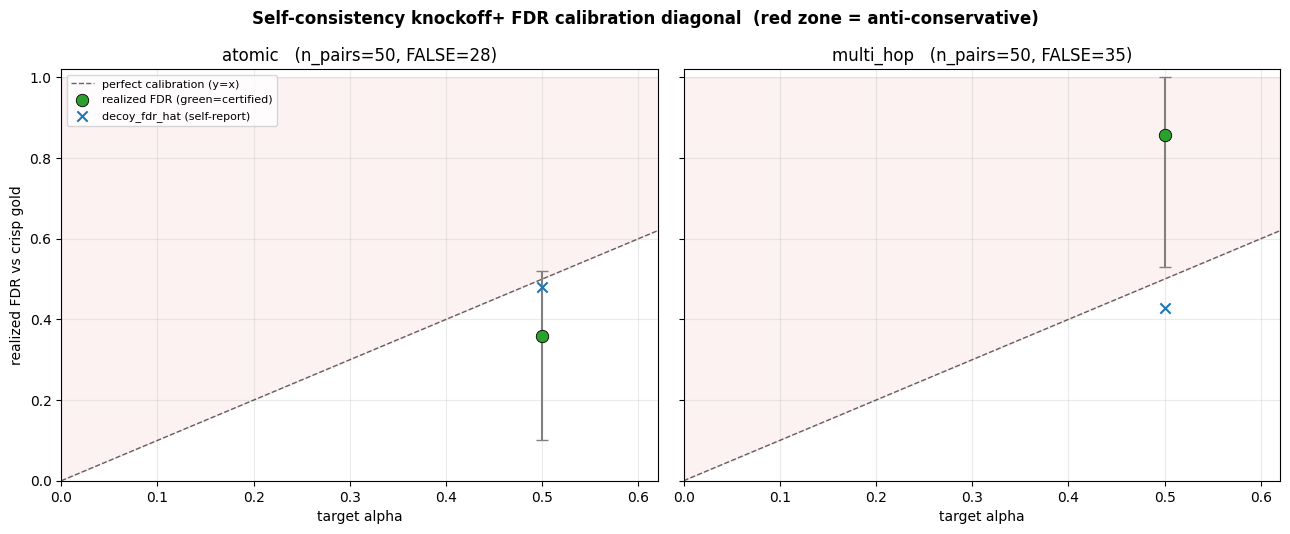


DEMO (100 records) vs FULL RUN reference  ----  multi_hop diagonal
   alpha  realized(demo)  realized(full)  n_adm(demo)  n_adm(full)
    0.05            None            None            0            0
     0.1            None            None            0            0
     0.2            None            None            0            0
     0.3            None            None            0            0
     0.5        0.857143             1.0            7           12

Full-run pre-registered verdict (multi_hop @ alpha*=0.5): DISCONFIRMED  (realized=1.0, CI=[0.661594, 1.0])
Demo verdict (this 100-record subset):                  DISCONFIRMED  (realized=0.857143, CI=[0.530147, 1.0])


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharey=True)
fams = ["atomic", "multi_hop"]
for ax, fam in zip(axes, fams):
    dg = diagonals[fam]
    xs, real, dfh, lo, hi, cert = [], [], [], [], [], []
    for r in dg["rows"]:
        if r["realized_fdr"] is None:   # alpha admitted nothing -> not plottable
            continue
        xs.append(r["target_alpha"]); real.append(r["realized_fdr"])
        dfh.append(r["decoy_fdr_hat"] if r["decoy_fdr_hat"] is not None else np.nan)
        lo.append(r["realized_fdr"] - (r["ci_low"] if r["ci_low"] is not None else r["realized_fdr"]))
        hi.append((r["ci_high"] if r["ci_high"] is not None else r["realized_fdr"]) - r["realized_fdr"])
        cert.append(r["certified"])
    grid = np.linspace(0, 1, 50)
    ax.plot(grid, grid, "k--", lw=1, alpha=0.6, label="perfect calibration (y=x)")
    ax.fill_between(grid, grid, 1.0, color="tab:red", alpha=0.06)   # anti-conservative region
    if xs:
        colors = ["tab:green" if c else "tab:orange" for c in cert]
        ax.errorbar(xs, real, yerr=[lo, hi], fmt="o", ms=9, capsize=4,
                    ecolor="gray", mfc="none", mec="none", zorder=2)
        ax.scatter(xs, real, c=colors, s=80, zorder=3, edgecolors="k", linewidths=0.6,
                   label="realized FDR (green=certified)")
        ax.scatter(xs, dfh, marker="x", c="tab:blue", s=55, zorder=3,
                   label="decoy_fdr_hat (self-report)")
    ax.set_title(f"{fam}   (n_pairs={dg['n_pairs']}, FALSE={dg['n_false_total']})")
    ax.set_xlabel("target alpha")
    ax.set_xlim(0, 0.62); ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
axes[0].set_ylabel("realized FDR vs crisp gold")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Self-consistency knockoff+ FDR calibration diagonal  (red zone = anti-conservative)",
             fontweight="bold")
fig.tight_layout()
plt.savefig("figure_diagonal_demo.png", dpi=110, bbox_inches="tight")
plt.show()

# ---- side-by-side: demo subset vs full ~593-doc run (multi_hop) ----
print("\nDEMO (100 records) vs FULL RUN reference  ----  multi_hop diagonal")
ref = {r["target_alpha"]: r for r in data["full_run_reference"]["multi_hop_rows"]}
print(f"  {'alpha':>6} {'realized(demo)':>15} {'realized(full)':>15} "
      f"{'n_adm(demo)':>12} {'n_adm(full)':>12}")
for r in diagonals["multi_hop"]["rows"]:
    a = r["target_alpha"]; fr = ref.get(a, {})
    print(f"  {a:>6} {str(r['realized_fdr']):>15} {str(fr.get('realized_fdr')):>15} "
          f"{r['n_admitted']:>12} {str(fr.get('n_admitted')):>12}")

fv = data["full_run_reference"]["primary_disconfirmation_verdict"]
print(f"\nFull-run pre-registered verdict (multi_hop @ alpha*={fv['alpha_star']}): "
      f"{fv['verdict']}  (realized={fv['realized_fdr']}, CI={fv['ci']})")
print(f"Demo verdict (this 100-record subset):                  {verdict['verdict']}  "
      f"(realized={verdict.get('realized_fdr')}, CI={verdict.get('ci')})")
